# Lecture 8: Matplotlib and Seaborn

#### Laboratory: Coding - Accounting, Finance and Business Consulting

## Introduction

### Visualizations in Data Analysis

- Visualizations are essential in data analysis and used for:
    - Exploratory Process
        - Identifying outliers, patterns in the data, appropriate modelling techniques, etc.
    - Communicating results
        - Be it plots for a technical audience or interactive web visualizations for the general public
- Python has a rich ecosystem of libraries for visualization, we will focus on **matplotlib** and **seaborn**


### Matplotlib

- MatPlotLib is a package for creating publication-quality plots and figures
    - Developed by John Hunter in 2002, and derived from MATLAB plotting interface
    - It is the most widely used data visualization library in Python (mostly indirectly)
    - Can create a wide variety of plots, including line plots, scatter plots, histograms, bar charts, etc.
- MatPlotLib allows to plot data from a variety of data formats:
    - Lists, tuples, dictionaries, pandas dataframes, numpy arrays, etc.
- MatPlotLib is a low-level library
    - Allows to control every aspect of a plot
    - It is not as intuitive and is more verbose than other libraries
    - More recent libraries are built on top of matplotlib and provide a higher-level interface

### Seaborn

- It is a Python library for data visualization based on the MatPlotLib library
    - Can create attractive and fairly complex graphics with few lines of code
- Provides functions and methods for drawing informative and attractive statistical plots
    - Tightly integrated with Pandas data structures
    - Works well with other packages that you might use for data analysis:
        - NumPy, SciPy, Pandas, StatsModels, etc.

### Matplotlib to Customize Plots

- Creating plots from scratch using MatPlotLib can be tedious
    - Libraries such as Seaborn are much more convenient
- MatPlotLib allows to customize some aspects of plots that are crucial and not accessible in seaborn
    - Create a panel with multiple plots, set the figure size, add a title or customize the legend
- There are countless aspects of a plot customizable using MatPlotLib
    - Going through all of them is beyond the scope of this course
    - We will first introduce some important aspects of MatPlotLib
    - We will then perform a toy data analysis using MatPlotLib and Seaborn


## Some Elements of MatPlotLib

### MatPlotLib Hirarchy
- MatPlotLib has a hierarchical structure
    - The figure is the top-level container for all the plot elements
    - The figure can contain multiple subplots
    - Each subplot is a container for all plot elements

### Figures and Subplots in MatPlotLib - How to create a Figure

- All plots in MatPlotLib are contained within a Figure object
    - Use `plt.figure` to initiate a new figure
- A blank figure cannot display plots directly
    - Use the `add_subplot` to create subplots (returning an Axes object)
    - The `add_subplot` method takes three main arguments:
        - `nrows` Number of rows
        - `ncols` Number of columns
        - `index` Index to identify the subplot (increase left to right, top to bottom)
        - If you call it with no arguments, it will create a single subplot by default


### Figures with a Single Plot

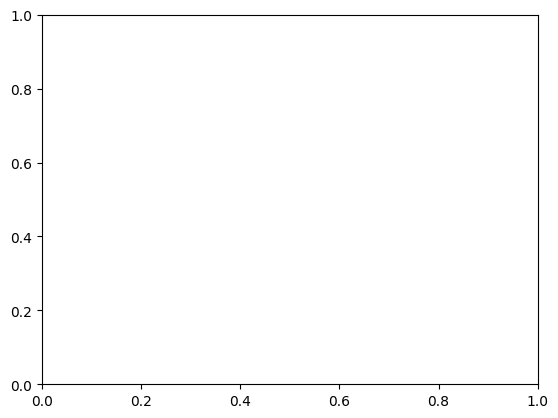

In [2]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax1 = fig.add_subplot()

### Figures With Multiple Subplots

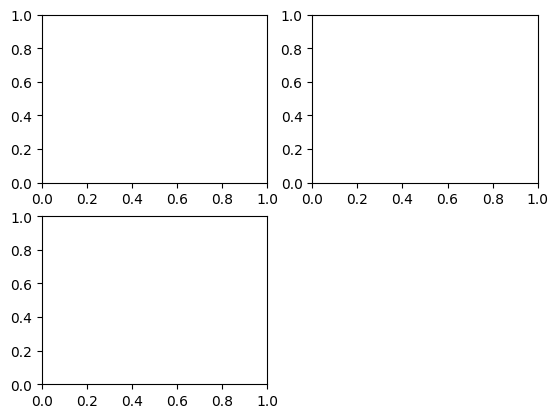

In [3]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

### Plotting in the Subplots
- You can plot inside the subplots using the methods
    -  `plot` for line plots
    -  `scatter` for scatter plots
    -  `hist` for histograms
    -  See all plots types in the [MatPlotLib documentation - Plot types](https://matplotlib.org/stable/plot_types/index.html)

### Plotting in the Subplots

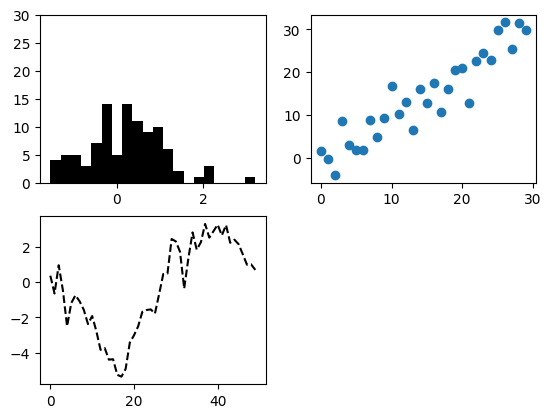

In [4]:
import numpy as np
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1, ylim=[0, 30])
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax1.hist(np.random.standard_normal(100), bins=20, color="black")#histogram of a standard normal 
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))#scatter plot of correlated variables
ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed");#line plot of a random walk

### Plotting in Jupyter
- In Jupyter notebooks plots are reset at each cell evaluation
    - We need to use all the plotting commands in the same cell
        - From defining the figure to each modification to the plots
- If you want to recall a plot that you already stored into a variable, use the `figure` attribute

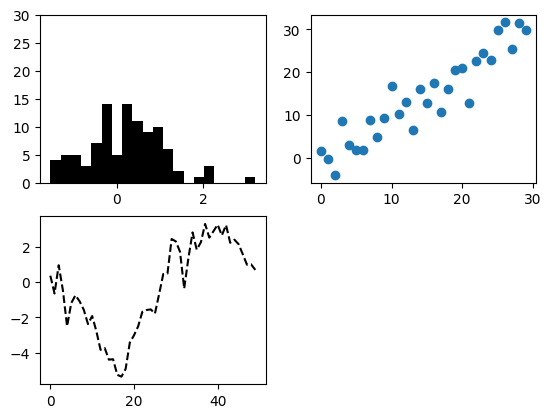

In [5]:
fig.figure

### Configuring Matplotlib

- Matplotlib's Default Settings are geared for publication-quality
    - They might not be ideal in the task at hand
- All the elements displayed can be modified
    - figure size, colors, font sizes, grid styles, etc.
- Done using the `rc` method:
    - It changes the default settings for all the plots in the notebook

### Common Options in Matplotlib's rc Method
- Figure Size and DPI:
    - Adjust default size and resolution (DPI) of figures
    - `plt.rc('figure', figsize=(8, 6), dpi=100)`
- Fonts and Font Sizes:
    - Set default font type and sizes for text in figures
    - `plt.rc('font', size=12, family='Arial')`
- Line Styles and Widths:
    - Customize default line styles and widths for plots.
    - `plt.rc('lines', linewidth=2, linestyle='-.')`

### Common Options in Matplotlib's rc Method
- Colors and Color Cycles:
    - Define default colors and color cycles for various plot elements
       - When plotting several lines/points, MatPlotLib cycles through the provided colors
    - `plt.rc('axes', prop_cycle=(cycler('color', ['red', 'green', 'blue', 'yellow'])))`
- Legend Configuration:
    - Configure default settings for legends like location (upper right) and frame (not displayed)
    - `plt.rc('legend', loc='upper right', frameon=False)`

## A Toy Data Analysis with Matplotlib and Seaborn


### A Toy Data Analysis with Matplotlib and Seaborn

- We will analyze a dataset that stores information on revenues, number of visitors, marketing spending and promotions by time (date/week/month/year) of a firm
- In this lecture we will mostly focus on the revenues by investigating:
    1. The revenues and their distribution
    2. The evolution of revenues in time
    3. The impact of promotions on revenues
    4. The impact of marketing spending on revenues

### Libraries Needed for the Analysis

In [6]:
import os 
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt # base graphical library
import seaborn as sns # seaborn graphical library
# seaborn is under active development and creates a lot of warnings that we ignore using this package and the following command
import warnings 
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.simplefilter("ignore", category=RuntimeWarning)

### Data Import

In [7]:
m_rawData = pd.read_csv('data/marketing_rawData.csv', sep=';') 
print(f"""Using the command
m_rawData = pd.read_csv('data/marketing_rawData.csv')
we read the data from marketing_rawData and store it in the variable m_rawData:""")
m_rawData

Using the command
m_rawData = pd.read_csv('data/marketing_rawData.csv')
we read the data from marketing_rawData and store it in the variable m_rawData:


,Date,Week,Week_ID,Month,Month_ID,Year,Day_Name,Visitors,Revenue,Marketing Spend,Promo
0,09/11/2020,46,34,11,11,2020,Monday,707.0,465.0,651.375000,No Promo
1,10/11/2020,46,34,11,11,2020,Tuesday,1455.0,10386.0,1298.250000,Promotion Red
2,11/11/2020,46,34,11,11,2020,Wednesday,1520.0,12475.0,1559.375000,Promotion Blue
3,12/11/2020,46,34,11,11,2020,Thursday,1726.0,11712.0,1801.750000,No Promo
4,13/11/2020,46,34,11,11,2020,Friday,2134.0,10000.0,2614.500000,No Promo
...,...,...,...,...,...,...,...,...,...,...,...
177,05/05/2021,19,60,5,17,2021,Wednesday,1400.0,7284.0,1119.600000,No Promo
178,06/05/2021,19,60,5,17,2021,Thursday,2244.0,13021.0,2067.888889,Promotion Red
179,07/05/2021,19,60,5,17,2021,Friday,2023.0,4587.0,1450.200000,No Promo
180,08/05/2021,19,60,5,17,2021,Saturday,1483.0,5927.0,1121.875000,No Promo


### A Basic Look at the Data - Data Types, Missing Values, and Summary Statistics

In [8]:
print(f"The command m_rawData.dtypes returns:\n\n{m_rawData.dtypes}")

The command m_rawData.dtypes returns:

Date                object
Week                 int64
Week_ID              int64
Month                int64
Month_ID             int64
Year                 int64
Day_Name            object
Visitors           float64
Revenue            float64
Marketing Spend    float64
Promo               object
dtype: object


### A Basic Look at the Data - Descriptive Statistics

In [9]:
print(f"The command m_rawData.describe() returns:\n{m_rawData.describe(include = 'all')}")

The command m_rawData.describe() returns:
              Date        Week     Week_ID       Month    Month_ID  \
count          182  182.000000  182.000000  182.000000  182.000000   
unique         182         NaN         NaN         NaN         NaN   
top     09/11/2020         NaN         NaN         NaN         NaN   
freq             1         NaN         NaN         NaN         NaN   
mean           NaN   21.785714   47.351648    5.269231   13.774725   
std            NaN   18.369841    7.892053    4.204580    1.783540   
min            NaN    1.000000   34.000000    1.000000   11.000000   
25%            NaN    8.000000   40.000000    2.000000   12.000000   
50%            NaN   14.000000   48.000000    4.000000   14.000000   
75%            NaN   47.000000   54.000000   11.000000   15.000000   
max            NaN   53.000000   61.000000   12.000000   17.000000   

               Year Day_Name     Visitors       Revenue  Marketing Spend  \
count    182.000000      182   175.000000

### A Basic Look at the Data - Missing Values

In [10]:
print(f"The command m_rawData.isnull().sum() returns:\n{m_rawData.isnull().sum()}")

The command m_rawData.isnull().sum() returns:
Date                0
Week                0
Week_ID             0
Month               0
Month_ID            0
Year                0
Day_Name            0
Visitors            7
Revenue            19
Marketing Spend     0
Promo               0
dtype: int64


### Analyzing the Missing Values

- We have missing values in the `Revenue` and `Visitors` columns
- To have a better understanding of the missing values we will:
    - Compute the percentage of missing values in each column
    - Investigate wethever the missing values tend to occur in a pattern
        - For example, are there specific months or days of the week with more missing values?

### Analyzing the Missing Values - Percentage of Missing Values

In [11]:
print(f"The percentage of missing values in the revenue column is {(m_rawData['Revenue'].isnull().sum() / len(m_rawData)) * 100:.2f}%")
print(f"The percentage of missing values in the visitors column is {(m_rawData['Visitors'].isnull().sum() / len(m_rawData)) * 100:.2f}%")

The percentage of missing values in the revenue column is 10.44%
The percentage of missing values in the visitors column is 3.85%


- The missing values in the `visitors` column are less than 4%, not marginal but not necessarely a big problem
- The missing values in the `revenue` column are slightly above the 10%, a more substantial amount
    - Depending on the setting, our result could already be considered unreliable

### Analyzing the Missing Values - Missing Revenue Obs by Month

In [12]:
print(f"""We can count the number of missing values in the 'Revenue' column by month using the command:
m_rawData.groupby(m_rawData['Month'])['Revenue'].apply(lambda x: x.isnull().sum())
that returns:\n\n{m_rawData.groupby(m_rawData['Month'])['Revenue'].apply(lambda x: x.isnull().sum())}\n""")

We can count the number of missing values in the 'Revenue' column by month using the command:
m_rawData.groupby(m_rawData['Month'])['Revenue'].apply(lambda x: x.isnull().sum())
that returns:

Month
1     3
2     5
3     2
4     2
5     1
11    3
12    3
Name: Revenue, dtype: int64



### Analyzing the Missing Values - Missing Visitors Obs by Month

In [13]:
print(f"The same command for the 'Visitors' columns returns:\n{m_rawData.groupby(m_rawData['Month'])['Visitors'].apply(lambda x: x.isnull().sum())}")

The same command for the 'Visitors' columns returns:
Month
1     1
2     0
3     2
4     1
5     0
11    1
12    2
Name: Visitors, dtype: int64


### Analyzing the Missing Values - Missing Values by Month
- In both columns, the missing values are not concentrated in specific months
- Note that, by doing this check we discovered an important feature of the data
    - The data provides info only on Months 1-5 and 11-12

### Analyzing the Missing Values - Missing Revenues Obs by Day of the Week

In [14]:
print(f"""To investigate the missing in 'Revenues' by day of the week we run:
m_rawData.groupby(m_rawData['Day_Name'])['Revenue'].apply(lambda x: x.isnull().sum())
we get:\n{m_rawData.groupby(m_rawData['Day_Name'])['Revenue'].apply(lambda x: x.isnull().sum())}\n""")

To investigate the missing in 'Revenues' by day of the week we run:
m_rawData.groupby(m_rawData['Day_Name'])['Revenue'].apply(lambda x: x.isnull().sum())
we get:
Day_Name
Friday        1
Monday        1
Saturday      2
Sunday       10
Thursday      2
Tuesday       2
Wednesday     1
Name: Revenue, dtype: int64



### Analyzing the Missing Values - Missing Vistors Obs by Day of the Week

In [15]:
print(f"While for 'Visitors':\n{m_rawData.groupby(m_rawData['Day_Name'])['Visitors'].apply(lambda x: x.isnull().sum())}")

While for 'Visitors':
Day_Name
Friday       0
Monday       1
Saturday     1
Sunday       2
Thursday     1
Tuesday      0
Wednesday    2
Name: Visitors, dtype: int64


### Analyzing the Missing Values - Missing Values by Day of the Week

- The missing values in the `Revenue` column are concentrated in the Sunday
    - More than 5 times the average number of missing values
    - This may point towards a problem with the data collection process 
        - Possibly Sundays are more busy and the staff is not able to keep up
- The missing values in the `Visitors` do not show a clear pattern

### 📈 Exercises: Compute the Describe Function for Missing/non-missing Observations

- Another possible informative exploration would invvestigate the difference in the distribution of the columns of the dataset between observations that have a missing value in the Revenue or Visitors column and the others  

To this end:
1. Group the dataset in observations that have a missing value in the Revenue column and the others
2. Compute describe on the columns [Marketing Spend, Day_Name, Promo, Visitors] of the grouped object
3. Do the same for the observations that have a missing value in the Visitors column 
    - Consider the columns [Marketing Spend, Day_Name, Promo, Revenue]
3. Do the same for the observations that have a missing value in the Revenue or Visitors column
    - Consider the columns [Marketing Spend, Day_Name, Promo]
5. Write a short summary of the result


### Dealing with the Missing Values
- Different settings require different approaches to deal with missing values
    - In a regression analysis, we might want to drop the missing observations 
    - In a time series analysis, we might want to fill the missing observations
- In our simple example, we will fill the missing values with the mean of the column
    - We will use the `fillna` method of pandas dataframes
    - We will use the `inplace` argument to modify the dataframe in place

### Dealing with the Missing Values - Filling with the Column Mean


In [16]:
m_rawData['Revenue'].fillna(m_rawData['Revenue'].mean(), inplace=True)
m_rawData['Visitors'].fillna(m_rawData['Visitors'].mean(), inplace=True)

### Dealing with the Missing Values - Checking the Imputation


In [17]:
missing_values = m_rawData.isnull().sum()
print(f"\nMissing Values:\n{missing_values}")


Missing Values:
Date               0
Week               0
Week_ID            0
Month              0
Month_ID           0
Year               0
Day_Name           0
Visitors           0
Revenue            0
Marketing Spend    0
Promo              0
dtype: int64


### 📈 Exercises: Filling the Missing Values by Group

- It seems likely that revenues vary by day of the week
    - Revenues on Sunday are likely to be different than on Monday
    - The same is true for the number of visitors
- We can improve our imputation of missing values by using the mean of day of the week
    - Filling the missing values on Sunday with the mean revenues of Sundays, and so on
1. Investigate wether revenues and visitors vary by day of the week (you will need to reload the data since our data-filling would bias this result)
2. Fill the missing values with the mean of the day of the week 
    - Hint: It is a matter of performing a custom operation on the groups based on the day of the week




### Distribution Plots
- Let's now investigate the distribution of revenues
    - Summary statistics are useful, but they remove a lot of information from the data
- Histograms are the most common plot to visualize the distribution of a variable
    - The variable is divided into bins, and the frequency of observations in each bin is represented by the height of the bar
- In seaborn, the `displot()` can be used to plot:
    - Histograms
    - Kernel density - a smoothed version of the histogram
    - Rugplots - consists of marks along an axis showing the position of each observation

### Histogram of Revenue
- In displot the only necessary argument is the variable to be plotted
    - The default number of bins is 10
    - The default type of plot is a histogram

### Histogram of Revenue


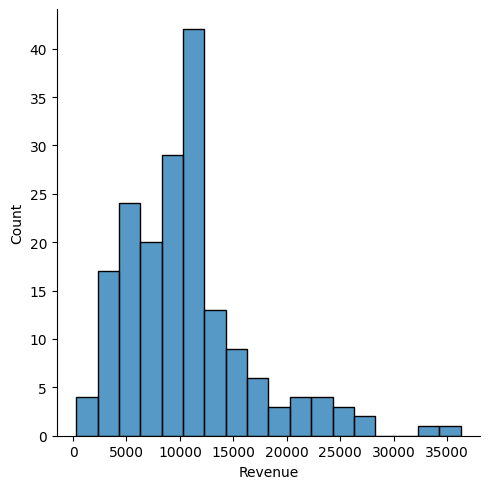

In [18]:
import warnings #to avoid having tedious warnings on the layout
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn.axisgrid")

hist_rev = sns.displot(m_rawData['Revenue'])

### Histogram, Kernel Density and Rugplot of Revenue 
- The parameter `kde=True` adds the kernel density to the plot
- The parameter `rug=True` adds the rugplot to the plot
- The parameter  `hist=False` removes the histogram
- We can change the number of bins by passing the parameter `bins`
- The colors of all the elements of the plot can be changed using  `color`, `kde_kws` and `rug_kws`
    

### Histogram, Kernel Density and Rugplot of Revenue 


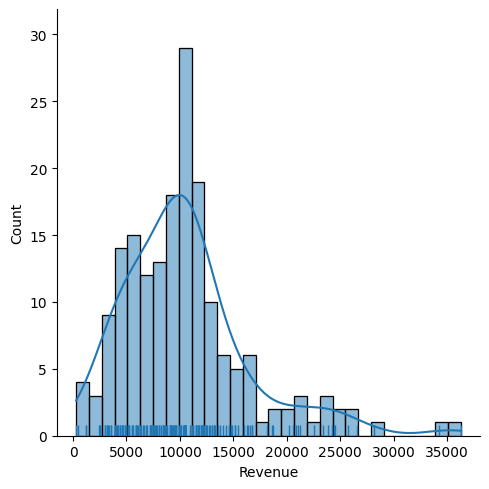

In [19]:
distrib_rev = sns.displot(m_rawData['Revenue'], kde = True, bins = 30, rug=True)

### Adding Lines to Plots
- It is possible to add lines to plots using the function `axvline()` and `axhline()`
    - `axvline()` adds a vertical line
    - `axhline()` adds an horizontal line
- Let's add to the previous plot a vertical line at the mean of the distribution


### Density Plot of Revenue - Adding Lines and Title

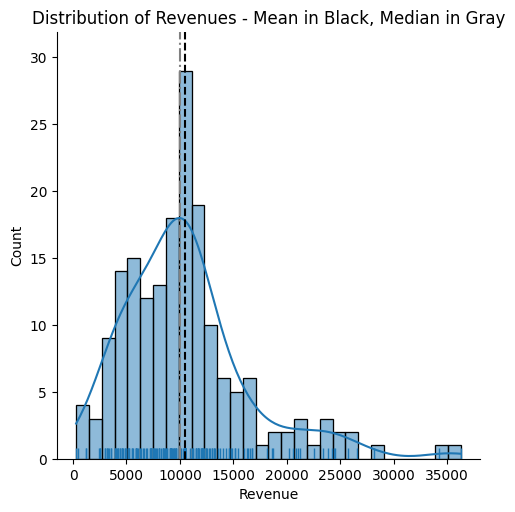

In [20]:
distrib_rev = sns.displot(m_rawData['Revenue'], kde = True, bins = 30, rug=True)
distrib_rev.set(title='Distribution of Revenues - Mean in Black, Median in Gray') # add title to the plot
distrib_rev.ax.axvline(x=m_rawData['Revenue'].mean(), color='black', linestyle='--')
distrib_rev.ax.axvline(x=m_rawData['Revenue'].median(), color='gray', linestyle='-.');

### Saving the Plots

- If you want to save the plots you can call the method `savefig()` of the figure object
    - The first argument is the path where you want to save the file (including the file format: png, jpg, etc.)
    - Use the argument `dpi` to set the resolution of the image (default is 72, 300 is good for publication)
    - The parameter `bbox_inches='tight'` adjusts the figure size and limits so that all content of the plot is included in the saved figure


In [21]:
distrib_rev.figure.savefig('plots/distrib_rev.png', dpi=300, bbox_inches='tight')

### A Basic Look at the Data - Number of Observations by Date and Week_ID
Let's have a look at how many observations we have at each `Date` and at `Week_ID`

In [22]:
print(f"Running sorted(m_rawData['Date'].value_counts().unique()) shows that we have one observation per day:\n{sorted(m_rawData['Date'].value_counts().unique())}\n")
print(f"Running sorted(m_rawData['Week_ID'].value_counts().unique() shows that we have different number of observations in different weeks:\n{m_rawData['Week_ID'].value_counts().unique()}\n")
print(f"Running m_rawData['Week_ID'].value_counts().value_counts().sort_index() we can see that the most weeks have 7 obs:\n{m_rawData['Week_ID'].value_counts().value_counts().sort_index()}\n")

Running sorted(m_rawData['Date'].value_counts().unique()) shows that we have one observation per day:
[np.int64(1)]

Running sorted(m_rawData['Week_ID'].value_counts().unique() shows that we have different number of observations in different weeks:
[7 6 5 2 1]

Running m_rawData['Week_ID'].value_counts().value_counts().sort_index() we can see that the most weeks have 7 obs:
count
1     1
2     1
5     1
6     1
7    24
Name: count, dtype: int64



### A Basic Look at the Data - Number of Observations by Date and Week_ID - An Explanation
- Running `m_rawData['Date'].value_counts()` returns a Series with the number of observations for each date
    - All of the dates only have one observation
- Running `m_rawData['Week_ID'].value_counts()` returns a Series with the number of observations for each week
    - Most of the weeks have 7 observations but there are occurences of 6, 5, 2, 1 observations
    - To investigate the relevance of these occurences we run `m_rawData['Week_ID'].value_counts().value_counts().sort_index()`
    - This computes, for each number of observations (7, 6, 5, 2, 1 ) the number of weeks that have that number of observations and sorts the results



### Lineplot

- A Lineplot displays data as points ('markers') connected by straight line segments
- It is used to track changes of a variable across another
    - Most commonly used to show trends over time
- It is a good choice when you have continuous/categorical measure and want to visualize it over time
   - Using different lines (with different colors, linetypes, markers, etc.) you can compare the evolution of the data across the different categories


### A Lineplot of Revenue by Date
- In our dataset we have the Revenue of a company for different
    - dates - weeks(Week_ID) - Month(Month_ID) - Years(Year)
- Lets plot the Revenue over Date using the function `sns.lineplot()`:
    - `x` specifies the column for the x-axis
    - `y` specifies the column for the y-axis
    - `data` specifies the DataFrame where `x` and `y` are stored
- In this lecture we will consider just the main parameters of `lineplot`
    - For the full list see the [lineplot documentation](https://seaborn.pydata.org/generated/seaborn.lineplot.html)  


### A Lineplot of Revenue by Date


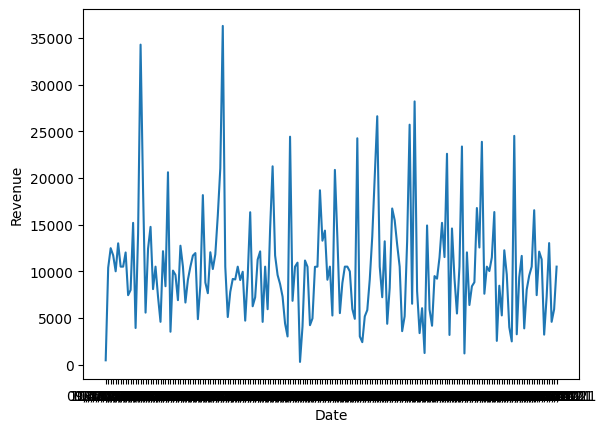

In [23]:
lineplot_rev_date = sns.lineplot(x='Date', y='Revenue', data = m_rawData)

### A Lineplot of Revenue by Date - Adding a Title and Improving Labels

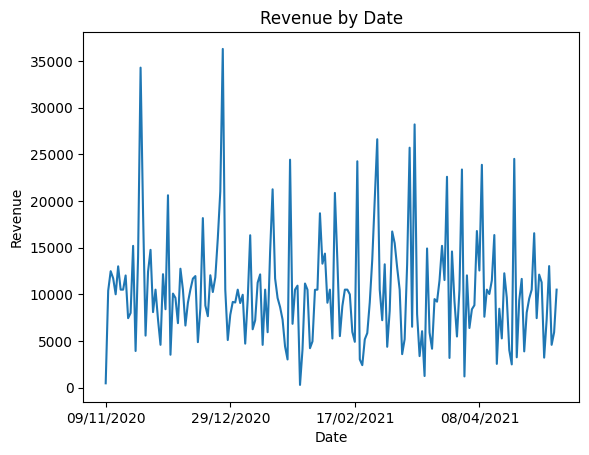

In [24]:
lineplot_rev_date = sns.lineplot(x='Date', y='Revenue', data = m_rawData)
# show only every 50th date to avoid overlapping
lineplot_rev_date.set_xticks(lineplot_rev_date.get_xticks()[::50]) 
# add title to the plot - notice that is slightly different from the one for displot
lineplot_rev_date.set_title('Revenue by Date');

### A Lineplot of Revenue by Week_ID
- As we have seen, there are many observations for each week
- If we try do a lineplot of Revenue vs Week_ID `seaborn` automatically:
    - Aggregates the data and plots the mean of the `Revenue` for each `Week_ID`
        - If you want to use a different aggregation (e.g., median) set it through the `estimator` parameter
    - Plots the 95% confidence interval of the mean
        - Use the `ci` parameter to set a different level (e.g., 99), ore remove it (i.e., False)

### A Lineplot of Revenue by Week_ID

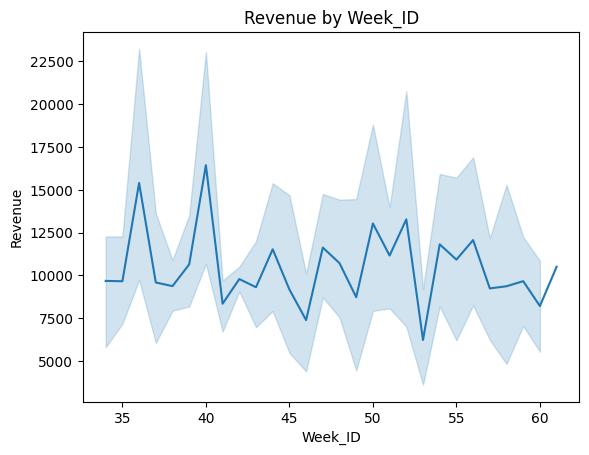

In [25]:
lineplot_rev_week = sns.lineplot(x='Week_ID', y='Revenue', data=m_rawData)
lineplot_rev_week.set_title('Revenue by Week_ID')  # add title to the plot
# save the figure as png to the plots folder
lineplot_rev_week.figure.savefig('plots/lineplot_rev_week.png', dpi=300, bbox_inches='tight') 

### A Basic Look at the Data  - Number of Promotions by Week_ID

In [26]:
print(f"The Promo column has {m_rawData['Promo'].nunique()} unique values:\n{m_rawData['Promo'].unique()}\n")

print(f"""We can have a look at its frequency table using the command
m_rawData.groupby('Week_ID')['Promo'].nunique().value_counts().sort_values() 
showing that in almost all weeks we have observations from all three promotions:\n\n{m_rawData.groupby('Week_ID')['Promo'].nunique().value_counts().sort_values()}""")

The Promo column has 3 unique values:
['No Promo' 'Promotion Red' 'Promotion Blue']

We can have a look at its frequency table using the command
m_rawData.groupby('Week_ID')['Promo'].nunique().value_counts().sort_values() 
showing that in almost all weeks we have observations from all three promotions:

Promo
1     2
2     3
3    23
Name: count, dtype: int64


### Lineplot of Revenues by Week_ID Grouped by Promotion
- Data can be displayed by group based on a column in the dataframe
- The groups can be represented as separate **lines** with:
    - Different **colors** for each group by passing the grouping column name to the `hue` parameter 
        - The color associated to each group can be set using the `palette` parameter
        - See [here](https://seaborn.pydata.org/tutorial/color_palettes.html) for more information on colors and palettes
    - Different **linetype** for each group by passing the grouping column name to the `style` parameter 
        - The linetype associated with each group can be set using the `dashes` parameter
        - See [here](https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html) for more information on dashes
- Much more can be customized in a lineplot


### Lineplot of PromotionRevenues by Week_ID Grouped by Promotion

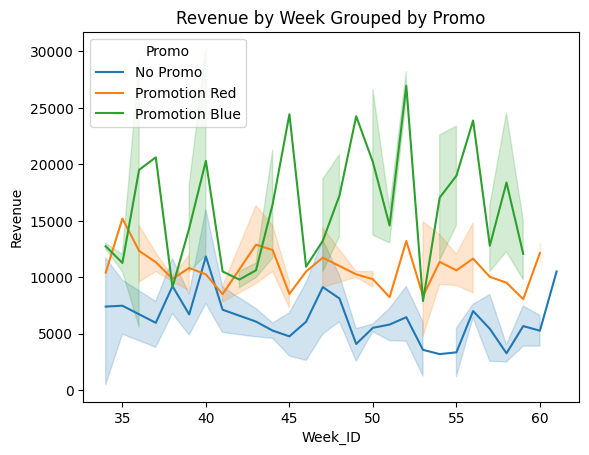

In [27]:
# The `hue` parameter groups the data based on the "Promo" column
lineplot_rev_week_promo = sns.lineplot(x='Week_ID', y='Revenue', hue='Promo', data=m_rawData)
# add title to the plot
lineplot_rev_week_promo.set_title('Revenue by Week Grouped by Promo');

### Lineplot of Revenues by Week_ID Grouped by Promotion - Adjusting Colors

Text(0.5, 1.0, 'Revenue by Week Grouped by Promo')

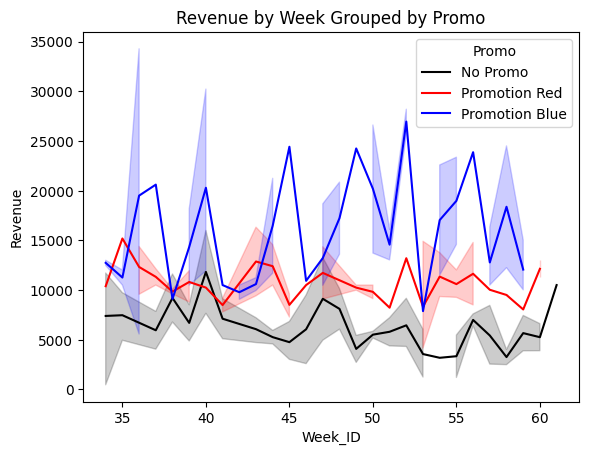

In [28]:
# The `palette` sets the colors to be used by the hue
lineplot_rev_week_promo = sns.lineplot(x='Week_ID', y='Revenue', hue='Promo',\
                                       palette=['black', 'red', 'blue'], data=m_rawData) 
lineplot_rev_week_promo.set_title('Revenue by Week Grouped by Promo')

### Lineplot of Revenues by Week_ID Grouped by Promotion - Adjusting Linetypes

Text(0.5, 1.0, 'Revenue by Week Grouped by Promo')

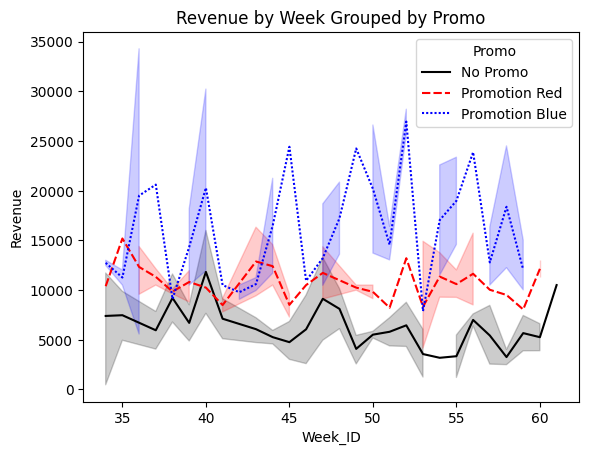

In [29]:
#The style parameter sets the line style 
lineplot_rev_week_promo = sns.lineplot(x='Week_ID', y='Revenue', hue='Promo', style = 'Promo', \
                                       palette=['black', 'red', 'blue'], data=m_rawData) 
lineplot_rev_week_promo.set_title('Revenue by Week Grouped by Promo')

### Lineplot of Revenues by Week_ID Grouped by Promotion - Further Adjustments

- In seaborn it is possible to set much of the style of the plot by using the function `set()`
    - The variable `rc` controls several things, including the size of the plot
        - We can set the "default" height and width of the plot in inches by passing it dictionary with the key `figure.figsize`
        - `sns.set(rc={'figure.figsize':(12,10)})`
        - It becomes the default for all the future plots in the notebook
- We can also plot the **markers** of each data point by setting `markers=True`

### Lineplot of Revenues by Week_ID Grouped by Promotion - Further Adjustments

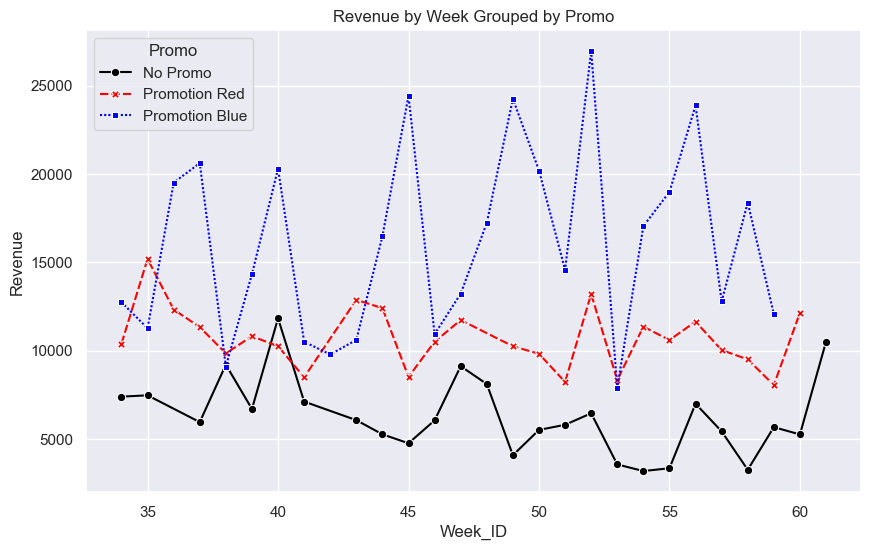

In [30]:
sns.set(rc={'figure.figsize':(10,6)})#set the dimensions of (all future) plots
lineplot_rev_week_promo = sns.lineplot(x='Week_ID', y='Revenue', hue='Promo', style = 'Promo', \
                          palette=['black', 'red', 'blue'], ci=None, markers=True, data=m_rawData)
lineplot_rev_week_promo.set_title('Revenue by Week Grouped by Promo');

### Lineplot of Revenues by Week_ID Grouped by Promotion - Saving and Re-setting Plot Size

In [31]:
# save the figure as png to the plots folder
lineplot_rev_week_promo.figure.savefig('plots/lineplot_rev_week_promo.png', dpi=300, bbox_inches='tight')
# set a smaller figure size for the rest of the notebook
sns.set(rc={'figure.figsize':(5, 3.75)})

### Comparing Distributions - Histograms and Kernel Density Using Hue
- Comparing distributions is a common task in data analysis
    - Often is useful to compare the distribution of a variable across groups
    - E.g., the distribution of revenues across different promotions or day of the week
- We might directly compare the histograms/kernel density of two variables
    - We can use the `displot()` using the `hue` argument
    - Often the result is hard to read since too much information is displayed

### Histogram and Kernel Density of Revenues by Promotion
- The `alpha` parameter sets the transparency of objects (1 total opacity, 0 total transparency)

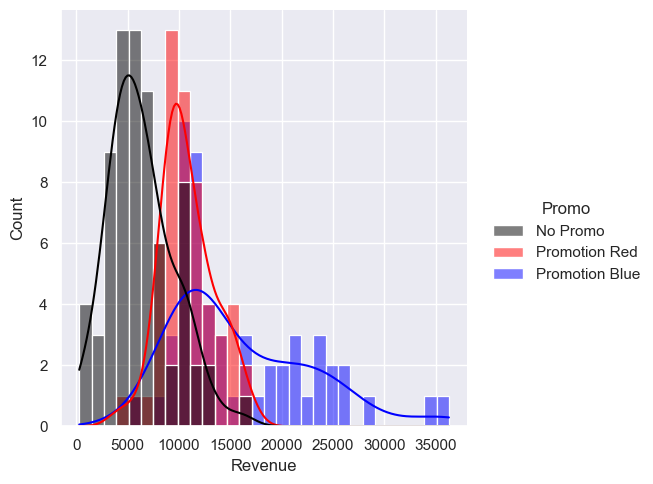

In [32]:
distrib_rev_promo = sns.displot(data=m_rawData, x='Revenue', hue='Promo', 
                                palette=['black', 'red', 'blue'], alpha=0.5, bins=30, kde=True);


### Comparing Distributions - Boxplots

- Boxplots are a visualization often used to summarize and convey information on distributions 
- Boxplots visualize five-number summary statistics of a distribution
    - The box represents the interquartile range (IQR)
    - The line in the box represents the median
    - The whiskers represent the range of the data
    - The dots represent the outliers
- In seaborn, the `boxplot()` function can be used to plot boxplots
    - The `hue` argument can be used to plot the boxplots of different groups

### Boxplot of Revenues by Promotion

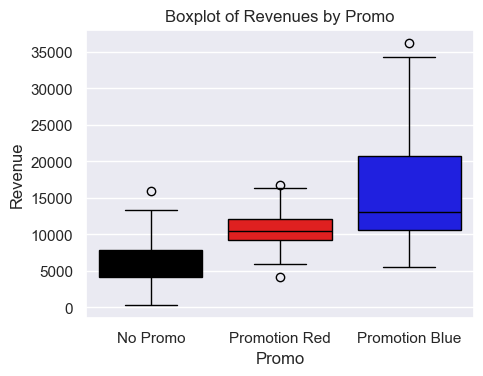

In [33]:
boxplot_rev_promo = sns.boxplot(x='Promo', y='Revenue', palette=['black', 'red', 'blue'], data=m_rawData)
boxplot_rev_promo.set_title('Boxplot of Revenues by Promo');

### Boxplot of Revenues by Promotion - Using Colors Improving Readability
- Visualizations entire point is to make the data easier to understand: **Form is Substance**
   -  Due to poor colour choice, the mean in the "NoPromo" intervals is hard to read
- Seaborn provides a set of color palettes functions
    - Return colors to be passed at hue in a variety of formats
    - The available palettes can be found in the [palette documentation](https://seaborn.pydata.org/tutorial/color_palettes.html)
    - In this example we use `light_palette()` to create a palette of light colors
      - We provide one argument (the color to use as a base), and extract with brackets the elements we need

### Barplot of Revenue by Month_ID Grouped by Promotion - Using Colors Improving Readability


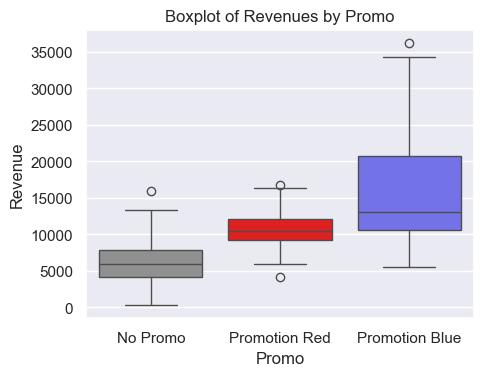

In [34]:
boxplot_rev_promo = sns.boxplot(x='Promo', y='Revenue', data=m_rawData,
                                palette=[sns.light_palette("black")[2], 'red', sns.light_palette("blue")[3]])
boxplot_rev_promo.set_title('Boxplot of Revenues by Promo');

### Comparing Distributions - Violinplots

- Violinplots are a visualization that is close in spirit to boxplots but:
    - Are more informative than boxplots
        - They display the density of the data
    - Are less common than boxplots
- In a violinplot:
    - The width of the violin represents the density of the data at that point
    - The white dot represents the median
    - The black box represents the interquartile range (IQR)
    - The black lines represent the range of the data

### Comparing Distributions - Violinplots

(Text(0.5, 1.0, 'Violinplot of Revenue by Promo'),)

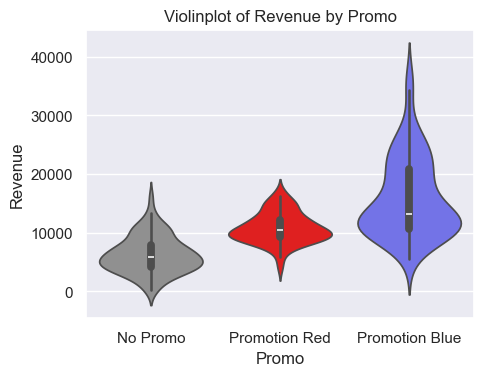

In [35]:
violinplot_rev_promo = sns.violinplot(x='Promo', y='Revenue', data=m_rawData,
                                      palette=[sns.light_palette("black")[2], 'red', sns.light_palette("blue")[3]])
violinplot_rev_promo.set_title('Violinplot of Revenue by Promo'),

### Bar Plots

- Bar plots are used to show the relationship between a numerical variable and a categorical variable
    - Each observation of the numerical variable with the same categorical value is grouped into the same visual object: a bar
    - The height of each bar is proportional to **a transformation** of the value of the numerical variables in that category (e.g., mean, count)
    - Bootstrapping is used to compute a confidence interval around the estimate
        - Bootstrapping is a statistical technique that involves sampling with replacement
- More information on Barplots can be found in the [Barplot documentation](https://seaborn.pydata.org/generated/seaborn.barplot.html)

### Analyzing the Revenue by Month_ID - Using a Table
- Let's say we are interested in investigating the Revenue in each month
- We already know how to create a table with the mean Revenue for each Month_ID, for example:

In [36]:
m_rawData.groupby('Month_ID').agg({'Revenue':'mean'})

,Revenue
Month_ID,
11,11417.315951
12,11164.320997
13,9231.127449
14,11101.794698
15,10638.267762
16,10377.210020
17,8373.516701


### Analyzing the Revenue by Month_ID - Using a Barplot
- A more immediate and informative way to convey the same information is to use a barplot
- By default the `barplot()` function:
    - Aggregates the observations in each category using the mean
        - The aggregation function can be set using the `estimator` parameter
    - Plots the 95% confidence interval of the mean
        - The parameter `ci` allows to customize the confidence intervals similar to lineplots

### Barplot of Revenue by Month_ID

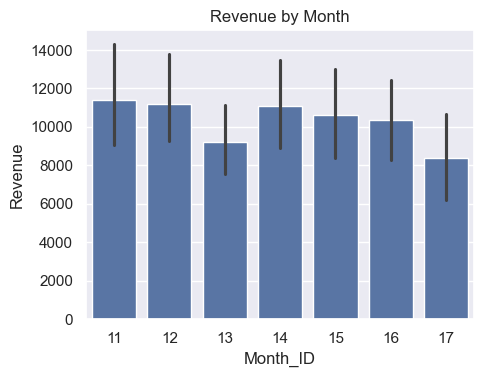

In [37]:
barplot_rev_month = sns.barplot(x="Month_ID", y="Revenue", data=m_rawData)
barplot_rev_month.set_title('Revenue by Month');

The barplot shows no statistically significant differences in Revenue between the different months

### Barplot of Revenue by Month_ID Grouped by Promotion

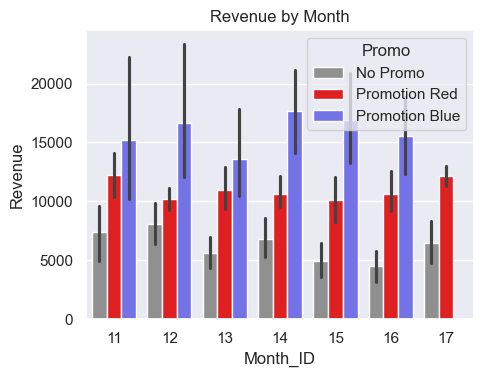

In [38]:
barplot_rev_month_promo = sns.barplot(x="Month_ID", y="Revenue", data=m_rawData, hue='Promo', \
                                      palette=[sns.light_palette("black")[2], 'red', sns.light_palette("blue")[3]])
barplot_rev_month_promo.set_title('Revenue by Month');

This plot suggests a Blue-Red-No Promo ordering of Revenue

### Barplot of Revenue by Month_ID Grouped by Promotion - Moving the Legend to Avoid Overlapping
- It is possible to move it to a different position by using the `bbox_to_anchor` parameter (so to avoid overlappings)
    - `bbox_to_anchor` specifies the anchor point of the legend
        - `(1, 1)` identifies the top-right corner of the plot
    - `loc` determines the location of the legend relative to the anchor point
        - `upper-left` positions the legend in that corner of the anchor point

### Barplot of Revenue by Month_ID Grouped by Promotion - Moving the Legend to Avoid Overlapping


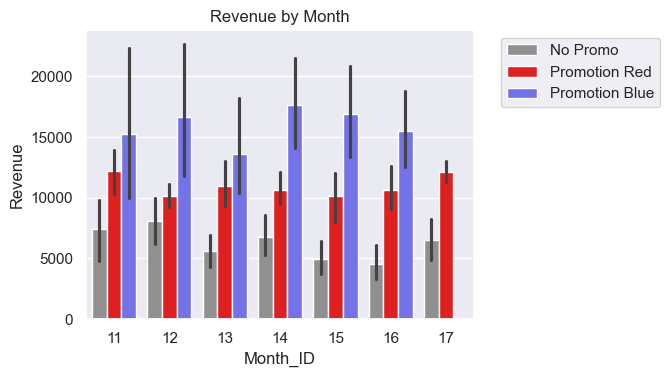

In [39]:
barplot_rev_month_promo = sns.barplot(x="Month_ID", y="Revenue", data=m_rawData, hue='Promo',
                                      palette=[sns.light_palette("black")[2], 'red', sns.light_palette("blue")[3]])
barplot_rev_month_promo.set_title('Revenue by Month')
# move the legend outside the plot
barplot_rev_month_promo.legend(bbox_to_anchor=(1.05, 1), loc='upper left');

### Barplot of Revenue by Year Grouped by Promotion 
- The previous plot displays some heterogeneity across promotions
    - At the high level of disaggregation of the Month_ID the picture is somewhat ambiguous
        - Especially in month 12 and 13)
- Let's first save it

In [40]:
barplot_rev_month_promo.figure.savefig('plots/barplot_rev_month_promo.png', dpi=300, bbox_inches='tight') 

- And continue investigate this lead by aggregating at the Year level
    - To improve readability we also flip the axes with `orient='h'`

### Barplot of Revenue by Year Grouped by Promotion 


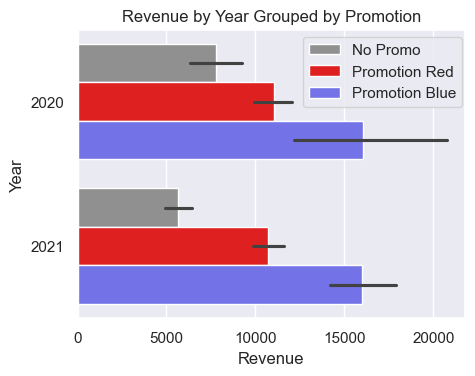

In [41]:
barplot_rev_year_promo = sns.barplot(x="Revenue", y="Year", hue='Promo', orient = 'h',
                 palette=[sns.light_palette("black")[2], 'red', sns.light_palette("blue")[3]], 
                 data=m_rawData)
barplot_rev_year_promo.set_title('Revenue by Year Grouped by Promotion')
barplot_rev_year_promo.legend(bbox_to_anchor=(.562, 1), loc='upper left');

### Barplot of Revenue by Year Grouped by Promotion 

- In this plot the relationship between the promotions and the revenues is much clearer
    - We save it for later presentation

In [42]:
barplot_rev_year_promo.figure.savefig('plots/barplot_rev_year_promo.png', dpi=300, bbox_inches='tight') # this plot brings home our main point, we save it for presentation 

### Scatterplots
- Scatterplots are best used to visualize the relationship between two numerical variables
    - The two variables of each observation are mapped to x-y coordinates
    - The points are not connected by lines
- The shape of the cloud of points provides a lot of information 
    - Hints at the presence of a possible relationships between the Variables
        - Increaseng/decreasing - Linear/Non-Linear 
    - Allows to identify outliers and clusters of observations
- More information on Scatterplots can be found in the [Scatterplot documentation](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)


### Scatterplots in Seaborn - Investigate the Impact of Marketing Spending on Revenue
- Apart from promotions, marketing spending is another variable that we might want to investigate
    - Create a scatterplot of Revenues by Marketing Spending
    - In Seaborn, this plot type is implemented by the `scatterplot()` function


### Scatterplots in Seaborn - Investigate the Impact of Marketing Spending on Revenue


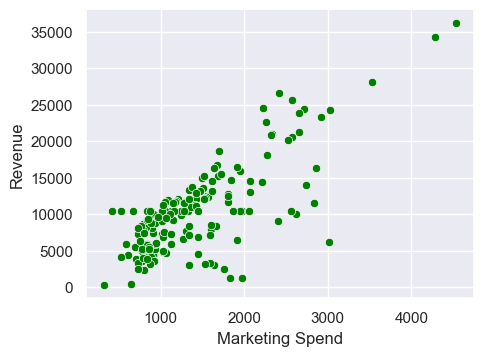

In [43]:
scatter_rev_mark = sns.scatterplot(x="Marketing Spend", y="Revenue", data=m_rawData, color = 'green')

Indeed it seems that there is a positive relationship between the two variables

### The Impact of Marketing Spending on Revenue Grouped by Promotion
- Again, we can group the data by another column using the `hue` and `style` parameters

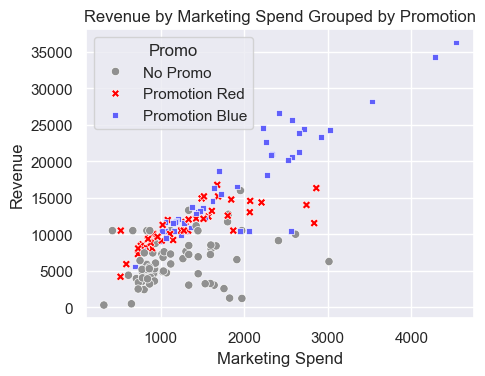

In [44]:
scatter_rev_mark_promo = sns.scatterplot(x="Marketing Spend", y="Revenue", data=m_rawData, hue = 'Promo', style = 'Promo', palette=[sns.light_palette("black")[2], 'red', sns.light_palette("blue")[3]])
scatter_rev_mark_promo.set_title('Revenue by Marketing Spend Grouped by Promotion');

### The Impact of Marketing Spending on Revenue Grouped by Promotion

- Marketing spending increases with revenues for all promotions
    - The relationship is stronger for the Blue promotion
    - The relationship is weakest for the no promotion group
    - The relationship is strong for the Red promotion until 2000\$ and then it weakens
- These are all interesting insights to guide managerial decisions, so we save the plot for later presentation

In [45]:
scatter_rev_mark_promo.figure.savefig('plots/scatter_rev_mark_promo.png', dpi=300, bbox_inches='tight')

### The Impact of Marketing Spending on Revenue Grouped by Promotion - The Role of Visitors
- We can add another layer of information to the plot using the `size` parameter
    - Not easy to read, but for big effects it can be useful
- Here we use the `size` parameter to investigate the role of Visitors

### The Impact of Marketing Spending on Revenue Grouped by Promotion - The Role of Visitors


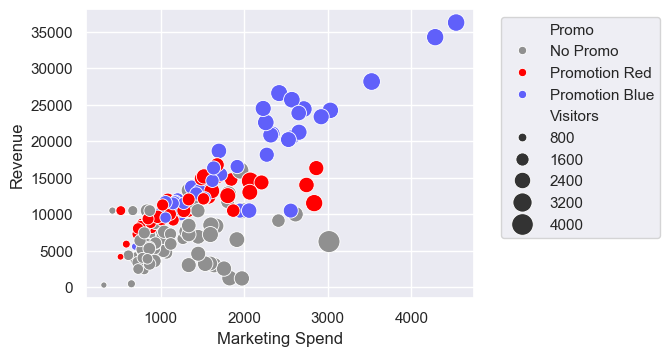

In [46]:
scatter_rev_mark_promo_visit = sns.scatterplot(x="Marketing Spend", y="Revenue", data=m_rawData, \
                                               hue='Promo', size='Visitors', sizes=(20, 250),\
                                               palette=[sns.light_palette("black")[2], 'red', sns.light_palette("blue")[3]])
scatter_rev_mark_promo_visit.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

### The Impact of Marketing Spending on Revenue Grouped by Promotion - The Role of Visitors


- It is not very clear if there is a relationship between Visitors and the other variables
    - Further investigation is needed, we save the plot that we will possibly use in future research

In [47]:
scatter_rev_mark_promo_visit.figure.savefig('plots/scatter_rev_mark_promo.png', dpi=300, bbox_inches='tight') # 

### Linear Regression
- Linear regression is used to investigate the relationship between (usually numerical) variables
    - The relationship is modeled using a linear function
    - The parameters of the line (intercept and slope) are estimated using the data
- As a visual tool, a linear regression line is often useful to complement a scatterplot
    - The slope of the line immediately provides a measure of the impact of one variable on the other

### Linear Regression in Seaborn - lmplot
- The function `lmplot()` can be used to display a scatterplot with a linear regression line
    - Includes a 95% confidence interval for the regression line (customizable through `ci`)
    - It is possible to add a polynomial regression by setting the `order` parameter
- Based on the usual parameters
    - The `hue` and `style` parameters can be used to group the data by other columns
        - Customizable as usual
- More information on lmplots can be found in the [lmplot documentation](https://seaborn.pydata.org/generated/seaborn.lmplot.html)


### The Impact of Marketing Spending on Revenue - Scatterplot with Linear Fit

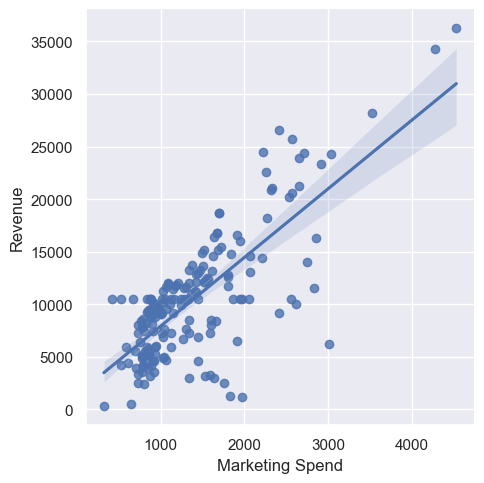

In [48]:
lm_rev_mark = sns.lmplot(x="Marketing Spend", y="Revenue", data=m_rawData) 

### The Impact of Marketing Spending on Revenue Grouped by Promotion - Scatterplot with Linear Fit

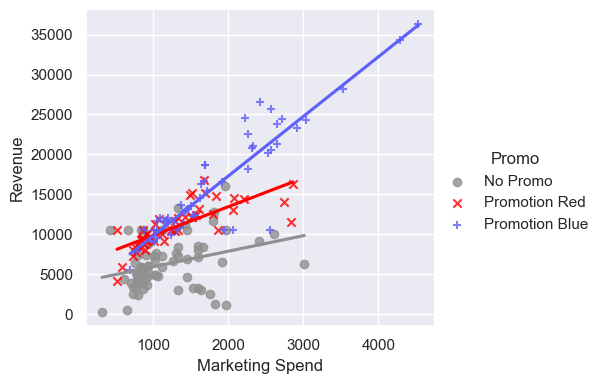

In [49]:
lm_rev_mark_promo = sns.lmplot(x="Marketing Spend", y="Revenue", data=m_rawData, hue = 'Promo', ci= False, 
        markers=["o", "x", "+"], palette=[sns.light_palette("black")[2], 'red', sns.light_palette("blue")[3]],
        height = 4, aspect = 1.2)# in lmplot we can set the size and aspect (ratio height to width) of the plot directly from the function 
lm_rev_mark_promo.figure.savefig('plots/scatter_rev_mark_promo.png', dpi=300, bbox_inches='tight')

### The Impact of Marketing Spending on Revenue Grouped by Promotion - Scatterplot with Linear Fit

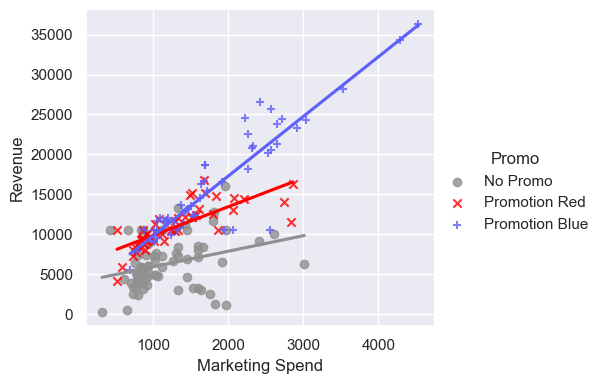

In [50]:
lm_rev_mark_promo.figure

The slope of the linear regression shows immediately a stronger relationship between Marketing Spending and Revenue for the Blue promotion

### Additional Resources on Data Visualization
- [Ch.9 of Python for Data Analysis](https://wesmckinney.com/book/numpy-basics)
- [Ch.4 of Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html)
- [Seaborn documentation](https://seaborn.pydata.org/)
- [Seaborn tutorials](https://seaborn.pydata.org/tutorial.html)
- [Seaborn examples gallery](https://seaborn.pydata.org/examples/index.html)
- [Matplotlib documentation](https://matplotlib.org/stable/contents.html)
- [Matplotlib tutorials](https://matplotlib.org/stable/tutorials/index.html)
- [Matplotlib examples gallery](https://matplotlib.org/stable/gallery/index.html)
- [Bonus - Animated charts!](https://medium.com/@necheverry_20468/improve-your-visualizations-with-animated-charts-in-python-19aa4624fe10)